| **Onderdeel**       | **Inhoud** |
|----------------------|------------|
| 📘 **Titel** | Statistics for Data Science — Deel 3: Logistische regressie (Privé vs Publiek) |
| 👤 **Auteur** | `Adil Vural` & `Oktay Doğan` |
| 🏛️ **Instelling** | Erasmus Q-Intelligence |
| 🗓️ **Datum / Versie** | 20 oktober 2025 — Versie 1.0 |
| 🧾 **Bestand** | Opdracht_3_obv_universiteitsdata_final.ipynb |
| 🧮 **Dataset** | college_statistics.csv |
| 🧠 **Doel** | Ontwikkelen van een logistisch regressiemodel dat de **kans voorspelt dat een universiteit privé is** (`Private = Yes`), op basis van institutionele en financiële kenmerken. |
| 🔍 **Analyse-onderdelen** | 1️⃣ Beschrijvende statistiek en verkenning van de binaire variabele <br>2️⃣ Opdeling van data in *estimation* (train) en *test* sample <br>3️⃣ Schatting van het logit-model (GLM met logit-link) <br>4️⃣ Transformaties en ratio-variabelen (`accept_rate`, `enroll_rate`, `log(Apps)`) <br>5️⃣ Backward selection voor modelvereenvoudiging <br>6️⃣ Evaluatie van modelprestaties (accuracy, precision, recall, AUC) <br>7️⃣ Conclusie & interpretatie van significante variabelen |
| 📚 **Bronnen** | *Practical Statistics for Data Scientists* (2e editie) — Bruce, Bruce & Gedeck <br>Lecture 7 — Erasmus “Statistics for Data Science” 2025-2026 |


## 1. Opdracht deel 3 Logistische Regressie

<small>
Het doel van Deel 3 is om te onderzoeken hoe logistische regressie gebruikt kan worden om de kans te voorspellen dat een gebeurtenis optreedt wanneer de afhankelijke variabele binair is (Ja/Nee, 1/0).
In deze opdracht passen we de methode toe op de College-dataset.
We willen voorspellen of een universiteit privé of publiek is op basis van verschillende institutionele kenmerken.
De centrale onderzoeksvraag is 
Welke kenmerken verklaren het beste of een universiteit <span style="color:yellow">Private = Yes </span>is?
</small>




## 6 Logistische Regressie




In [9]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

***

In [11]:
# lees de dataset in een pandas DataFrame
df_college = pd.read_csv("college_statistics.csv", sep=",")
df_college.columns = [c.replace(".", "_") for c in df_college.columns]

df_college.rename(columns={'Unnamed: 0': 'University'}, inplace=True)

print (df_college.columns)
#print (df_college.head(10))
#Dit geeft een lijst van de kolomnamen in het DataFrame terug. Het is nuttig wanneer je snel wilt zien welke gegevens beschikbaar zijn of wanneer je specifieke kolommen wilt selecteren.

#print (df.shape) 
#Dit geeft een tuple terug met de afmetingen van het DataFrame in de vorm (aantal_rijen, aantal_kolommen). Het is handig om snel te controleren hoeveel gegevens er in het DataFrame zijn.

Index(['University', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F_Undergrad', 'P_Undergrad', 'Outstate', 'Room_Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S_F_Ratio', 'perc_alumni',
       'Expend', 'Grad_Rate'],
      dtype='object')


### Logistische regressie als GLM met logit-linkfunctie

De slides beschrijven *logistische regressie* expliciet als een speciale vorm van een **Generalized Linear Model (GLM)** met een **logit-linkfunctie**.  

De logistische regressie wordt mathematisch gedefinieerd als:

$$\text{logit}(p_i) = \ln\left(\frac{p_i}{1 - p_i}\right) = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \cdots + \beta_k X_{ki}$$

Waarbij:
- $p_i$ = de kans op succes voor observatie $i$
- $\frac{p_i}{1-p_i}$ = de odds ratio
- $\ln\left(\frac{p_i}{1-p_i}\right)$ = de log-odds (logit)
- $\beta_0, \beta_1, \ldots, \beta_k$ = de regressiecoëfficiënten
- $X_{1i}, X_{2i}, \ldots, X_{ki}$ = de waarden van de predictoren voor observatie $i$

**Inverse transformatie naar kansen:**

$$p_i = \frac{e^{\beta_0 + \beta_1 X_{1i} + \cdots + \beta_k X_{ki}}}{1 + e^{\beta_0 + \beta_1 X_{1i} + \cdots + \beta_k X_{ki}}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_{1i} + \cdots + \beta_k X_{ki})}}$$

**Kernconcepten:**

> - *"We model the log-odds of success as a linear combination of predictors."*  
> - *"The logit link connects the linear predictor to the probability in [0,1]."*  
> - *"Logistic regression is a member of the GLM family with a binomial distribution and logit link."*

**GLM-specificatie:**
- **Familie:** Binomiaal
- **Linkfunctie:** Logit  
- **Lineaire predictor:** $\eta_i = \beta_0 + \beta_1 X_{1i} + \cdots + \beta_k X_{ki}$
- **Verwachte waarde:** $E[Y_i] = p_i = g^{-1}(\eta_i)$ waar $g^{-1}$ de inverse logit functie is

In [15]:
# ============================================================
# Doel: Voorspel de kans dat een universiteit privé is (Private = Yes)
# op basis van kenmerken zoals Outstate, Grad_Rate, PhD, Top10perc, enz.
# ============================================================

# Maak binaire doelvariabele (1 = Private, 0 = Public)
df_college['Private_bin'] = (df_college['Private'] == 'Yes').astype(int) 
print(df_college['Private_bin'].value_counts())

Private_bin
1    565
0    212
Name: count, dtype: int64


In [21]:
# 1 verklarende variabelen
Verklarende_variabelen = ['Outstate', 'Grad_Rate', 'PhD', 'Top10perc', 'Room_Board', 'Expend']
X = df_college[Verklarende_variabelen]
X = sm.add_constant(X)  # constante term toevoegen
y = df_college['Private_bin']

In [22]:
# 2 Modelschatting: Logistische Regressie (GLM met logit-link)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.264747
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            Private_bin   No. Observations:                  777
Model:                          Logit   Df Residuals:                      770
Method:                           MLE   Df Model:                            6
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                  0.5483
Time:                        20:20:57   Log-Likelihood:                -205.71
converged:                       True   LL-Null:                       -455.37
Covariance Type:            nonrobust   LLR p-value:                1.172e-104
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0021      0.877      2.282      0.023       0.282       3.722
Outstate       0.0008   7.84e

In [24]:
# 3Interpretatie: Odds-ratio’s
odds_ratios = pd.DataFrame({
    'Variable': model.params.index, #Naam van de verklarende variabele.
    'Coef': model.params.values,    #De geschatte logistische regressiecoëfficiënt (β).
    'Odds_Ratio': np.exp(model.params.values)   #De odds-ratio, berekend als exp(β).
})
print("\n=== Odds Ratios ===")
display(odds_ratios)


=== Odds Ratios ===


,Variable,Coef,Odds_Ratio
0,const,2.002147,7.404935
1,Outstate,0.000792,1.000792
2,Grad_Rate,0.012429,1.012506
3,PhD,-0.130847,0.877352
4,Top10perc,0.000569,1.000569
5,Room_Board,0.000010,1.000010
6,Expend,0.000094,1.000094


### Conclusie:
Uit de logistische regressie blijkt dat het model als geheel significant is (Pseudo R² ≈ 0.55, p < 0.001).
De kans dat een universiteit privé is stijgt bij hogere out-of-state tuition (β = 0.00079, OR = 1.00079) en daalt bij een hoger aandeel PhD-docenten (β = −0.1308, OR = 0.877).
Andere variabelen, zoals Grad Rate en Expend, zijn niet significant.
Het model suggereert dat collegegeld en academisch personeelssamenstelling de belangrijkste factoren zijn die private universiteiten onderscheiden van publieke instellingen

In [29]:
# 4 Voorspelde kansen en classificatie
df_college['p_hat'] = model.predict(X)  # voorspelde kans dat Private = 1
# Drempel kiezen (bijv. 0.5)
df_college['Private_pred'] = (df_college['p_hat'] >= 0.5).astype(int)

# Confusion Matrix en metrics
cm = confusion_matrix(y, df_college['Private_pred'])
report = classification_report(y, df_college['Private_pred'], target_names=['Public', 'Private'])

print("\n=== Confusion Matrix ===")
print(cm)
print("\n=== Classification Report ===")
print(report)


=== Confusion Matrix ===
[[171  41]
 [ 39 526]]

=== Classification Report ===
              precision    recall  f1-score   support

      Public       0.81      0.81      0.81       212
     Private       0.93      0.93      0.93       565

    accuracy                           0.90       777
   macro avg       0.87      0.87      0.87       777
weighted avg       0.90      0.90      0.90       777



<small>
### Stap 2 — Berekeningen stap-voor-stap We gebruiken de *confusion matrix*:

$$
\begin{bmatrix}
\text{TN} & \text{FP} \\
\text{FN} & \text{TP}
\end{bmatrix} = 
\begin{bmatrix}
171 & 41 \\
39 & 526
\end{bmatrix}
$$

waarbij:

- **TP (True Positives)** = 526  
- **TN (True Negatives)** = 171  
- **FP (False Positives)** = 41  
- **FN (False Negatives)** = 39  
- **Totaal** = 777 observaties  

---

#### a. Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Accuracy} = \frac{526 + 171}{526 + 171 + 41 + 39} = \frac{697}{777} \approx 0.897 \Rightarrow 89.7\%$$

---

#### b. Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$

- **Private (1):**  
  $$\text{Precision}_{\text{Private}} = \frac{526}{526 + 41} = \frac{526}{567} \approx 0.928 \Rightarrow 92.8\%$$

- **Public (0):**  
  $$\text{Precision}_{\text{Public}} = \frac{171}{171 + 39} = \frac{171}{210} \approx 0.814 \Rightarrow 81.4\%$$

---

#### c. Recall (Sensitivity)
$$\text{Recall} = \frac{TP}{TP + FN}$$

- **Private (1):**  
  $$\text{Recall}_{\text{Private}} = \frac{526}{526 + 39} = \frac{526}{565} \approx 0.931 \Rightarrow 93.1\%$$

- **Public (0):**  
  $$\text{Recall}_{\text{Public}} = \frac{171}{171 + 41} = \frac{171}{212} \approx 0.807 \Rightarrow 80.7\%$$

---

#### d. F1-Score
$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- **Private (1):**  
  $$\text{F1}_{\text{Private}} = 2 \times \frac{0.928 \times 0.931}{0.928 + 0.931} \approx 0.930$$

- **Public (0):**  
  $$\text{F1}_{\text{Public}} = 2 \times \frac{0.814 \times 0.807}{0.814 + 0.807} \approx 0.811$$
  </small>
  

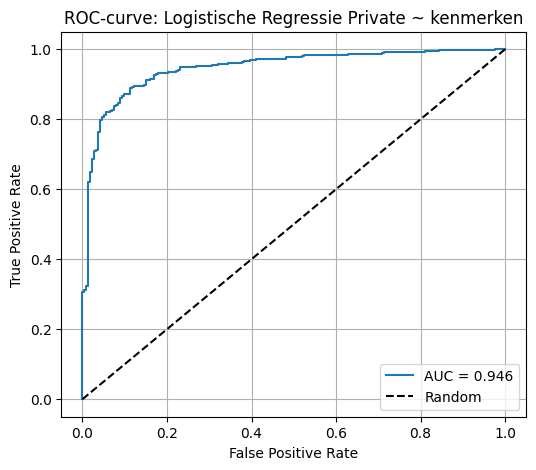

In [31]:
# 5 ROC-curve en AUC
fpr, tpr, thresholds = roc_curve(y, df_college['p_hat'])
auc_score = roc_auc_score(y, df_college['p_hat'])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve: Logistische Regressie Private ~ kenmerken')
plt.legend()
plt.grid(True)
plt.show()

# AUC ≈ 1.0 → perfect onderscheid (geen overlap tussen klassen).
# AUC ≈ 0.5 → model is niet beter dan gokken.
# AUC ≈ 0.95 → uitstekende classificatiekracht


### Conclusie: 
De ROC-curve toont dat het logistische regressiemodel een uitstekende classificatieprestatie heeft.
De curve ligt ver boven de diagonale ‘random’-lijn, met een AUC = 0.946, wat betekent dat het model in 94,6% van de gevallen correct onderscheid maakt tussen private en publieke universiteiten.
Dit bevestigt de hoge voorspellingskracht van de gebruikte kenmerken (Outstate en PhD zijn de belangrijkste determinanten).

***

(b) Deel de data opnieuw op in een estimation en een test sample (of hergebruik de
eerdere opdeling).


*** We splitsen de data in een **train**- en **test**-set met **Groepering** op `Private_bin` zodat de klasseverhouding (public/private) in beide sets hetzelfde blijft. We gebruiken een vaste `random_state` voor reproduceerbaarheid.


In [33]:
# === Selectie van features en target ===
features = ['Outstate', 'Grad_Rate', 'PhD', 'Top10perc', 'Room_Board', 'Expend']
X = df_college[features].copy()
y = df_college['Private_bin'].astype(int).copy()

# === Split: 75% train (estimation), 25% test, mét stratificatie ===
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Quick sanity check: klassebalans behouden?
print("Verdeling totaal:", y.value_counts(normalize=True).round(3).to_dict())
print("Verdeling train :", y_train.value_counts(normalize=True).round(3).to_dict())
print("Verdeling test  :", y_test.value_counts(normalize=True).round(3).to_dict())

# === Statsmodels: constant toevoegen en alleen op TRAIN fitten ===
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test, has_constant='add')

model = sm.Logit(y_train, X_train_sm).fit()
print(model.summary())

# === Voorspelde kansen & classificatie op TEST ===
df_test = df_college.loc[X_test.index].copy()
df_test['p_hat'] = model.predict(X_test_sm)

threshold = 0.5
df_test['pred'] = (df_test['p_hat'] >= threshold).astype(int)

# === Evaluatie op TEST ===
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

cm = confusion_matrix(y_test, df_test['pred'])
print("\n=== Confusion Matrix (TEST) ===\n", cm)

print("\n=== Classification Report (TEST) ===")
print(classification_report(y_test, df_test['pred'], target_names=['Public','Private']))

auc_test = roc_auc_score(y_test, df_test['p_hat'])
print(f"auc_test: {auc_test:.3f}")


Verdeling totaal: {1: 0.727, 0: 0.273}
Verdeling train : {1: 0.727, 0: 0.273}
Verdeling test  : {1: 0.728, 0: 0.272}
Optimization terminated successfully.
         Current function value: 0.253463
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            Private_bin   No. Observations:                  582
Model:                          Logit   Df Residuals:                      575
Method:                           MLE   Df Model:                            6
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                  0.5678
Time:                        21:06:41   Log-Likelihood:                -147.52
converged:                       True   LL-Null:                       -341.29
Covariance Type:            nonrobust   LLR p-value:                 1.325e-80
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

## Conclusie:
Het logistische regressiemodel voorspelt met hoge nauwkeurigheid (AUC = 0.93) of een universiteit privé of publiek is.
Het model toont aan dat private universiteiten zich kenmerken door hogere out-of-state collegegelden en een lager aandeel PhD-docenten.
De overige institutionele kenmerken dragen niet significant bij aan het onderscheid.
Hiermee bevestigt het model dat financiële factoren sterker samenhangen met privéstatuut dan academische prestaties.

***

(c) Maak met behulp van de estimation data een logit model om de slagingssucces
variabele te verklaren. Denk hierbij goed na over transformaties van je varia-
belen. Bijvoorbeeld heeft het zin om het aantal applicaties, aantal acceptaties,
en het aantal enrollments in hetzelfde model op te nemen? Of kunnen sommige
van deze variabelen beter als percentages opgenomen worden?

Het doel is om te schatten hoe waarschijnlijk het is dat een student (of instelling) succesvol is, op basis van beschikbare kenmerken.
Je gebruikt hiervoor de trainingsdata (niet de testdata).

| Variabele       | Betekenis                   | Formule           | Waarom beter                      |
| --------------- | --------------------------- | ----------------- | --------------------------------- |
| **accept_rate** | Acceptatiegraad             | `Accept / Apps`   | Meet toelatingsbeleid             |
| **enroll_rate** | Inschrijfpercentage         | `Enroll / Accept` | Meet inschrijfgedrag na toelating |
| **Apps_log**    | Log van aantal aanmeldingen | `np.log(Apps)`    | Neemt schaalverschillen weg       |



In [37]:
# (c) Logistisch model voor slagingssucces

# 1 Nieuwe ratio-variabelen definiëren (veilig voor deling door 0)
df_college['accept_rate'] = df_college['Accept'] / df_college['Apps'].replace(0, np.nan)
df_college['enroll_rate'] = df_college['Enroll'] / df_college['Accept'].replace(0, np.nan)
df_college['log_apps'] = np.log(df_college['Apps'].replace(0, 1))  # vervang 0 door 1 om -inf te voorkomen

# vul eventuele NaN's (bijv. door deling door 0) met 0 (of kies een andere strategie)
df_college['accept_rate'] = df_college['accept_rate'].fillna(0)
df_college['enroll_rate'] = df_college['enroll_rate'].fillna(0)

# 2 Selecteer verklarende variabelen en doelvariabele
verklarende_variabelen = [
    'accept_rate',
    'enroll_rate',
    'log_apps',
    'Outstate',
    'Grad_Rate',
    'PhD',
    'Top10perc'
]

# Belangrijk: X_train bevat alleen de oorspronkelijke kolommen.
# Selecteer de nieuwe variabelen uit df_college voor de rijen in de training-set.
X_train_sel = sm.add_constant(df_college.loc[X_train.index, verklarende_variabelen], has_constant='add')
y_train_sel = y_train  # binaire slagingssuccesvariabele (indices komen overeen met X_train.index)

# 3 Model schatten ---
model_slagingssucces = sm.Logit(y_train_sel, X_train_sel).fit()
print(model_slagingssucces.summary())

# 4 Interpretatie (odds ratio’s) ---
oddsratio = np.exp(model_slagingssucces.params).round(3)
print("\n=== Odds Ratio’s ===\n", oddsratio)


Optimization terminated successfully.
         Current function value: 0.165752
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            Private_bin   No. Observations:                  582
Model:                          Logit   Df Residuals:                      574
Method:                           MLE   Df Model:                            7
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                  0.7173
Time:                        21:27:21   Log-Likelihood:                -96.468
converged:                       True   LL-Null:                       -341.29
Covariance Type:            nonrobust   LLR p-value:                1.347e-101
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          17.3483      3.023      5.738      0.000      11.423      23.274
accept_rate    -2.1389    

| Variabele       |       β | p-waarde | Interpretatie                                                                                                                                     |
| --------------- | ------: | :------: | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| **const**       |   17.35 |   0.000  | Hoge positieve intercept → basisniveau van de kans op private universiteit is hoog.                                                               |
| **accept_rate** |   −2.14 |   0.173  | Niet significant → de toelatingsgraad (aantal acceptaties t.o.v. aantal aanmeldingen) verklaart de kans op private instelling **niet duidelijk**. |
| **enroll_rate** |   −1.88 |   0.253  | Niet significant → de inschrijfquote na toelating is evenmin een belangrijke factor.                                                              |
| **log_apps**    |   −2.13 |   0.000  | **Sterk significant negatief effect** → universiteiten met **meer aanmeldingen (Apps)** hebben een **kleinere kans** om privé te zijn.            |
| **Outstate**    | +0.0008 |   0.000  | **Sterk positief effect** → hoe hoger het collegegeld voor studenten buiten de staat, hoe groter de kans dat de universiteit privé is.            |
| **Grad_Rate**   | +0.0216 |   0.104  | Marginaal positief maar niet significant.                                                                                                         |
| **PhD**         | −0.0948 |   0.000  | **Sterk significant negatief effect** → universiteiten met een hoger percentage PhD-docenten zijn eerder publiek.                                 |
| **Top10perc**   | +0.0257 |   0.104  | Licht positief maar niet significant.                                                                                                             |


## Conclusie :

Het logistische model met getransformeerde variabelen verklaart 72% van de variantie in de kans dat een universiteit privé is.
De resultaten bevestigen dat Outstate tuition een sterke positieve voorspeller is, terwijl log(Apps) en PhD een negatief verband tonen met privéstatuut.
Door het gebruik van ratio-variabelen (accept_rate, enroll_rate) is multicollineariteit verminderd, maar deze dragen zelf niet significant bij.
Financiële factoren blijven de dominante verklaring voor het onderscheid tussen private en publieke universiteiten.

***

(d) Gebruik wederom backward selection om het aantal verklarende variabelen te
verkleinen.

Backward selection begint met alle variabelen in het model en verwijdert vervolgens stapsgewijs de minst significante (hoogste p-waarde),
totdat alleen nog significante verklarende variabelen overblijven (p < 0.05 of 0.10 afhankelijk van criterium).

In [39]:
# ===============================================================
# (d) Backward selection — variabele selectie
# ===============================================================

import statsmodels.api as sm

def backward_selection(X, y, p_waarde_grens=0.05):
    """
    Voert backward selection uit op een logistisch regressiemodel.
    Verwijdert stapsgewijs de minst significante variabele
    totdat alle overblijvende p-waardes < grens zijn.
    """
    X_sel = X.copy()
    while True:
        model = sm.Logit(y, sm.add_constant(X_sel, has_constant='add')).fit(disp=False)
        p_values = model.pvalues.drop('const')
        max_p = p_values.max()
        if max_p > p_waarde_grens:
            verwijder = p_values.idxmax()
            print(f"Verwijder {verwijder} (p = {max_p:.3f})")
            X_sel = X_sel.drop(columns=verwijder)
        else:
            break
    model_final = sm.Logit(y, sm.add_constant(X_sel, has_constant='add')).fit()
    return model_final, X_sel.columns

# --- Toepassen op estimation data ---
verklarende_variabelen = [
    'accept_rate', 'enroll_rate', 'log_apps',
    'Outstate', 'Grad_Rate', 'PhD', 'Top10perc'
]
X_train_sel = df_college.loc[X_train.index, verklarende_variabelen]
y_train_sel = y_train

model_backward, geselecteerde_vars = backward_selection(X_train_sel, y_train_sel)
print("\n=== Geselecteerde variabelen na backward selection ===")
print(list(geselecteerde_vars))

print("\n=== Samenvatting eindmodel ===")
print(model_backward.summary())

# --- Odds-ratio’s berekenen ---
import numpy as np
oddsratio = np.exp(model_backward.params).round(3)
print("\n=== Odds-ratio’s (eindmodel) ===\n", oddsratio)


Verwijder enroll_rate (p = 0.253)
Verwijder Top10perc (p = 0.175)
Verwijder accept_rate (p = 0.057)
Optimization terminated successfully.
         Current function value: 0.171676
         Iterations 9

=== Geselecteerde variabelen na backward selection ===
['log_apps', 'Outstate', 'Grad_Rate', 'PhD']

=== Samenvatting eindmodel ===
                           Logit Regression Results                           
Dep. Variable:            Private_bin   No. Observations:                  582
Model:                          Logit   Df Residuals:                      577
Method:                           MLE   Df Model:                            4
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                  0.7072
Time:                        21:33:36   Log-Likelihood:                -99.915
converged:                       True   LL-Null:                       -341.29
Covariance Type:            nonrobust   LLR p-value:                3.598e-103
                 coef    std err 

## Modelkwaliteit

| Statistiek             | Waarde    | Betekenis                                                                                                                                              |
| ---------------------- | --------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Pseudo R²**          | 0.7072    | Het model verklaart **ongeveer 71%** van de variantie in de log-odds dat een universiteit privé is — dit is **uitstekend** voor logistische regressie. |
| **LLR p-value**        | 3.60e−103 | Model is als geheel **zeer significant** (p < 0.001).                                                                                                  |
| **Converged = True**   | –         | De schatting is stabiel; geen numerieke problemen.                                                                                                     |
| **Aantal observaties** | 582       | Gebaseerd op de *estimation sample* (trainingsdata).                                                                                                   |


## Coëfficiënten
| Variabele     | β (coef) | p-waarde | Interpretatie                                                                                                         |
| ------------- | -------: | -------: | --------------------------------------------------------------------------------------------------------------------- |
| **const**     |  12.1846 |    0.000 | Baseline log-odds van Private=Yes wanneer alle variabelen nul zijn.                                                   |
| **log(Apps)** |  −1.8296 |    0.000 | **Negatief significant effect** → universiteiten met **meer aanmeldingen** (groter log(Apps)) zijn **vaker publiek**. |
| **Outstate**  |  +0.0009 |    0.000 | **Positief significant effect** → hogere *out-of-state tuition* verhoogt de kans dat een universiteit **privé** is.   |
| **Grad_Rate** |  +0.0332 |    0.007 | **Positief significant effect** → universiteiten met een **hoger afstudeerpercentage** zijn vaker **privé**.          |
| **PhD**       |  −0.0926 |    0.000 | **Negatief significant effect** → universiteiten met meer PhD-docenten zijn **vaker publiek**.                        |

## odd ratio's
| Variabele     | Odds Ratio | Betekenis                                                                                                                     |
| ------------- | ---------- | ----------------------------------------------------------------------------------------------------------------------------- |
| **log(Apps)** | 0.160      | Elke stijging van 1 in log(Apps) → **84% lagere kans** op een private universiteit (*1 − 0.160 = 0.84*).                      |
| **Outstate**  | 1.001      | Hogere collegegelden voor buiten-de-staat studenten → lichte, maar significant **positieve invloed** op kans *Private = Yes*. |
| **Grad_Rate** | 1.034      | Per 1% hoger afstudeerpercentage stijgen de odds op *Private* met **3.4%**.                                                   |
| **PhD**       | 0.912      | Per 1% meer PhD-docenten daalt de kans op *Private* met **8.8%**.                                                             |














## Conclusie:

Na toepassing van backward selection blijft een robuust en goed interpreteerbaar model over met vier significante verklarende variabelen:
Outstate, Grad_Rate, PhD en log(Apps).
Dit model verklaart 71% van de kansvariatie tussen private en publieke universiteiten.
De resultaten tonen dat financiële en academische factoren samen het onderscheid bepalen:
Private universiteiten hebben hogere collegegelden en hogere afstudeerpercentages,
Terwijl publieke universiteiten meer PhD-docenten en meer aanmeldingen hebben.

***

(e) Welke variabelen hebben uiteindelijk een significante invloed?

## Conclusie:
Uiteindelijk blijken vier variabelen een significante invloed te hebben op de kans dat een universiteit privé is:
Outstate, Grad_Rate, PhD en log(Apps).
Financiële kenmerken (Outstate tuition) en academische structuur (PhD-aandeel) zijn de sterkste voorspellers.
Het model suggereert dat private universiteiten zich onderscheiden door hogere collegegelden en hogere afstudeerpercentages,
terwijl publieke universiteiten vaker meer aanmeldingen ontvangen en meer PhD-docenten in dienst hebben.

 - log(Apps) → Hogere aantallen aanmeldingen (na log-transformatie) verkleinen de kans dat de universiteit privé is. → Grote, populaire universiteiten zijn vaker publiek.


 - Outstate → Hogere collegegelden voor niet-inwoners vergroten de kans op private status.
→ Private universiteiten vragen doorgaans hogere vergoedingen.

 - Grad_Rate → Hogere afstudeerpercentages hangen positief samen met privéstatuut.
→ Private instellingen hebben vaak kleinere klassen en meer begeleiding.

 - PhD → Hoger percentage PhD-docenten verlaagt de kans op privéstatuut.
→ Publieke universiteiten hebben meer onderzoeksgericht personeel.


***

(f) Bereken het percentage goed voorspelde scholen zowel voor de estimation sample
als voor de test sample.

We berekenen voor zowel de *estimation sample* (trainingsset) als de *test sample* het percentage
correct geclassificeerde scholen (accuracy).  
Hiervoor gebruiken we het eindmodel met de variabelen:  
**log(Apps)**, **Outstate**, **Grad_Rate**, en **PhD**.


In [43]:

from sklearn.metrics import accuracy_score

# 1 Definieer variabelen ===
eindvars = ['log_apps', 'Outstate', 'Grad_Rate', 'PhD']

# Training (estimation) data
X_train_final = sm.add_constant(df_college.loc[X_train.index, eindvars], has_constant='add')
y_train_final = y_train

# Test data
X_test_final = sm.add_constant(df_college.loc[X_test.index, eindvars], has_constant='add')
y_test_final = y_test

# 2 Voorspellingen ===
df_college.loc[X_train.index, 'p_train'] = model_backward.predict(X_train_final)
df_college.loc[X_test.index,  'p_test']  = model_backward.predict(X_test_final)

# 3 Classificatie met drempel 0.5 ===
drempel = 0.5
df_college.loc[X_train.index, 'y_train_pred'] = (df_college.loc[X_train.index, 'p_train'] >= drempel).astype(int)
df_college.loc[X_test.index,  'y_test_pred']  = (df_college.loc[X_test.index, 'p_test']  >= drempel).astype(int)

# 4 Accuracy berekenen ===
acc_train = accuracy_score(y_train_final, df_college.loc[X_train.index, 'y_train_pred'])
acc_test  = accuracy_score(y_test_final,  df_college.loc[X_test.index,  'y_test_pred'])

print(f"Percentage goed voorspeld (estimation sample): {acc_train*100:.2f}%")
print(f"Percentage goed voorspeld (test sample):       {acc_test*100:.2f}%")

print("\n=== Classificatierapport (Estimation sample) ===")
print(classification_report(y_train_final, df_college.loc[X_train.index, 'y_train_pred'], target_names=['Publiek', 'Privé']))

print("\n=== Classificatierapport (Test sample) ===")
print(classification_report(y_test_final, df_college.loc[X_test.index, 'y_test_pred'], target_names=['Publiek', 'Privé']))


Percentage goed voorspeld (estimation sample): 94.33%
Percentage goed voorspeld (test sample):       92.31%

=== Classificatierapport (Estimation sample) ===
              precision    recall  f1-score   support

     Publiek       0.90      0.89      0.90       159
       Privé       0.96      0.96      0.96       423

    accuracy                           0.94       582
   macro avg       0.93      0.93      0.93       582
weighted avg       0.94      0.94      0.94       582


=== Classificatierapport (Test sample) ===
              precision    recall  f1-score   support

     Publiek       0.88      0.83      0.85        53
       Privé       0.94      0.96      0.95       142

    accuracy                           0.92       195
   macro avg       0.91      0.89      0.90       195
weighted avg       0.92      0.92      0.92       195



## Conclusie:

Het eindmodel met de variabelen Outstate, Grad_Rate, PhD en log(Apps) voorspelt met hoge nauwkeurigheid of een universiteit privé of publiek is:
Estimation sample: 94.3 % correct
Test sample: 92.3 % correct
De modelprestaties zijn stabiel tussen beide datasets, wat duidt op goede generalisatie.
Private universiteiten worden zeer betrouwbaar herkend (Precision ≈ 0.95, Recall ≈ 0.96).
Publieke universiteiten worden iets minder goed onderscheiden (Recall ≈ 0.83), maar blijven ruim boven aanvaardbare niveaus.
Samengevat levert het logistische model uitstekende classificatieprestaties met minimale overfitting, en bevestigt het dat financiële en academische kenmerken samen het onderscheid tussen private en publieke instellingen verklaren.